In [ ]:
import pandas as pd
import pyarrow.parquet as pq
from glob import glob
import re
from tqdm import tqdm

path_pattern = "/work/hdd/bbjs/shared/corpora/vaani_iisc/Vaani/audio/**/*parquet"
metadata_path = "/work/hdd/bbjs/shared/corpora/vaani_iisc/Vaani/pincode_metadata.csv"

paths = glob(path_pattern, recursive=True)
print(f"Found {len(paths)} parquet files")

# Prepare pincode to lat/long mapping
# pin2latlong = pd.read_csv(metadata_path)[["Pincode", "Latitude", "Longitude"]]
# def to_float(x):
#     x = str(x).strip()
#     # extract the first float-like number (handles 72.7N, 12.9E, etc.)
#     m = re.search(r"([-+]?\d+(?:\.\d+)?)", x)
#     return float(m.group(1)) if m else None


# df = pd.read_csv(metadata_path).dropna(subset=["Pincode", "Latitude", "Longitude"])
# df["Pincode"] = df["Pincode"].astype(str).str.extract(r"(\d{6})")[0]
# df["Latitude"] = df["Latitude"].apply(to_float)
# df["Longitude"] = df["Longitude"].apply(to_float)
# df.dropna(inplace=True)

# pin2latlong = df.groupby("Pincode", as_index=False)[["Latitude", "Longitude"]].mean()
# print("Unique pincodes:", pin2latlong.shape)
# print(pin2latlong.head())

# pincodes = set()
# for idx, path in tqdm(enumerate(paths), total=len(paths)):
#     pf = pq.ParquetFile(path)
#     rg = pf.num_row_groups
#     for rg_idx in range(rg):
#         table = pf.read_row_group(rg_idx, columns=["pincode"])
#         pincodes.update(set(table["pincode"].to_pylist()))
# print("Unique pincodes in data:", len(pincodes))


# Explore a sample parquet file
# path = paths[0]
# pf = pq.ParquetFile(path)
# import torchaudio
# import io

# print("Schema:", pf.schema)
# print("Number of row groups:", pf.num_row_groups)
# relevant_columns = ["audio", "pincode"]

# for rg_idx in [0, 4]:
#     table = pf.read_row_group(rg_idx)
#     print(table.column_names, "column names")
#     row = {n: table[n][0].as_py() for n in relevant_columns}
#     print(len(row), row.keys())
#     audio = row["audio"]
#     pincode = row["pincode"]
#     print("Audio length (bytes):", len(audio))
#     print(type(audio), audio.keys())
#     b = audio["bytes"]
#     wav, sr = torchaudio.load(io.BytesIO(b))
#     print(wav.shape, sr)
#     print("Pincode:", pincode)
#     # save wav to file
#     out_wav_path = f"sample_rg{rg_idx}_pin{pincode}.wav"
#     torchaudio.save(out_wav_path, wav, sr)
#     break

Found 6470 parquet files
Schema: <pyarrow._parquet.ParquetSchema object at 0xfff34937edc0>
required group field_id=-1 schema {
  optional group field_id=-1 audio {
    optional binary field_id=-1 bytes;
    optional binary field_id=-1 path (String);
  }
  optional binary field_id=-1 language (String);
  optional binary field_id=-1 languagesKnown (String);
  optional binary field_id=-1 gender (String);
  optional binary field_id=-1 state (String);
  optional binary field_id=-1 district (String);
  optional int64 field_id=-1 pincode;
  optional binary field_id=-1 stay(years) (String);
  optional binary field_id=-1 isTranscriptionAvailable (String);
  optional binary field_id=-1 transcript (String);
  optional binary field_id=-1 referenceImage (String);
}

Number of row groups: 28
['audio', 'language', 'languagesKnown', 'gender', 'state', 'district', 'pincode', 'stay(years)', 'isTranscriptionAvailable', 'transcript', 'referenceImage'] column names
2 dict_keys(['audio', 'pincode'])
Audio l

In [13]:
import pandas as pd

vaani_metadata_path = "/work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/notebook/vaani_geolocation_metadata.csv"
df = pd.read_csv(vaani_metadata_path)
df

,parquet_path,row_group,row_index,pincode,latitude,longitude,audio_length
0,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,0,43,515722,14.514558,77.555600,5.350313
1,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,1,1,515751,14.562746,77.544900,8.579000
2,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,0,45,515201,13.823167,77.501403,4.332000
3,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,0,7,515556,13.896944,78.051667,12.285000
4,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,1,13,515164,14.101942,77.608581,16.010687
...,...,...,...,...,...,...,...
8995,Vaani/audio/AndhraPradesh/Annamaya/train-00004...,21,23,516214,13.917119,78.665864,4.285000
8996,Vaani/audio/AndhraPradesh/Annamaya/train-00004...,21,72,516269,14.044516,78.726561,3.617000
8997,Vaani/audio/AndhraPradesh/Annamaya/train-00004...,21,39,516269,14.044516,78.726561,3.350000
8998,Vaani/audio/AndhraPradesh/Annamaya/train-00004...,21,92,516214,13.917119,78.665864,2.533000


Unique pincodes in metadata: 103


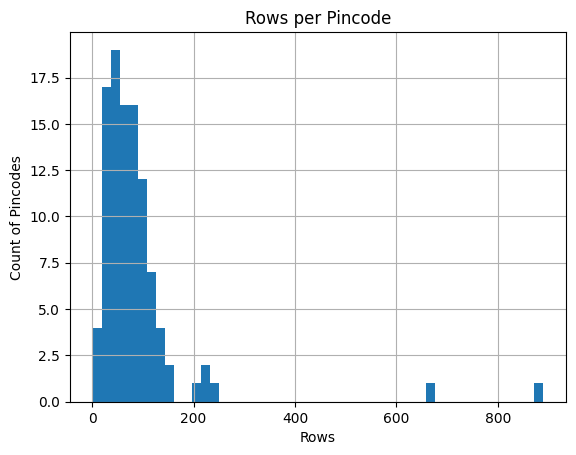

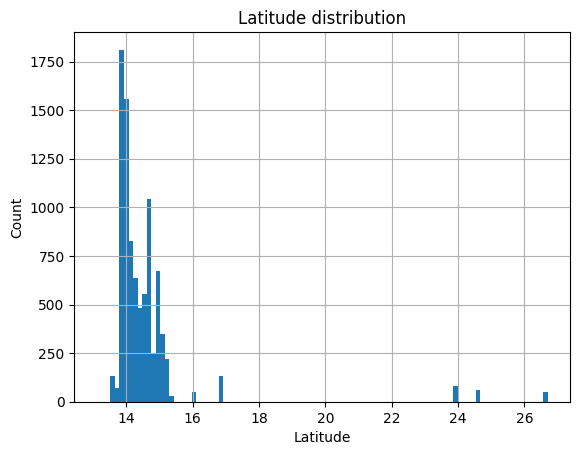

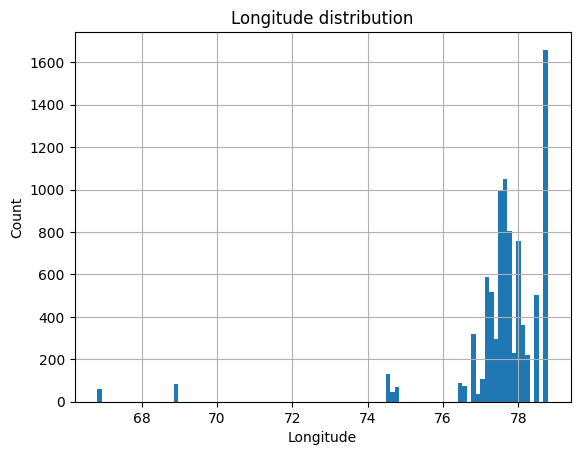

Test set size: (902, 7)
                                           parquet_path  row_group  row_index  \
3896  Vaani/audio/AndhraPradesh/Anantpur/train-00041...         16         69   
4358  Vaani/audio/AndhraPradesh/Anantpur/train-00041...         20         46   
2900  Vaani/audio/AndhraPradesh/Anantpur/train-00041...          4         86   
5555  Vaani/audio/AndhraPradesh/Anantpur/train-00043...         10         92   
495   Vaani/audio/AndhraPradesh/Anantpur/train-00047...          4          6   

      pincode   latitude  longitude  audio_length  
3896   515001  14.676325  77.594984      3.861312  
4358   515001  14.676325  77.594984      1.462875  
2900   515001  14.676325  77.594984      1.232250  
5555   515001  14.676325  77.594984      4.507000  
495    515001  14.676325  77.594984     12.254000  
Validation set size: (805, 7)
                                           parquet_path  row_group  row_index  \
1816  Vaani/audio/AndhraPradesh/Anantpur/train-00047...         18

/tmp/ipykernel_3488109/3797285845.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=TEST_FRAC, random_state=SEED_TEST))
/tmp/ipykernel_3488109/3797285845.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=VAL_FRAC, random_state=SEED_VAL))


In [ ]:
##########################################################################################
##########################################################################################
import matplotlib.pyplot as plt

# --- 1) Pincode stats + histogram of rows per pincode ---
print("Unique pincodes in metadata:", df["pincode"].nunique())
pincode_counts = df["pincode"].value_counts()
ax = pincode_counts.hist(bins=50)
ax.set_title("Rows per Pincode")
ax.set_xlabel("Rows")
ax.set_ylabel("Count of Pincodes")
plt.show()

# --- 2) Latitude and longitude histograms ---
plt.figure()
ax = df["latitude"].hist(bins=100)
ax.set_title("Latitude distribution")
ax.set_xlabel("Latitude")
ax.set_ylabel("Count")
plt.show()

plt.figure()
ax = df["longitude"].hist(bins=100)
ax.set_title("Longitude distribution")
ax.set_xlabel("Longitude")
ax.set_ylabel("Count")
plt.show()
##########################################################################################
##########################################################################################

# --- 3) Balanced splits by pincode without overlap ---
TEST_FRAC = 0.10
VAL_FRAC = 0.10  # applied on the remaining data (not on full df)
SEED_TEST = 42
SEED_VAL = 43  # different seed so we don't re-pick the same rows

# Keep original indices so we can drop reliably
test_idx = (
    df.groupby("pincode", group_keys=False)
    .apply(lambda g: g.sample(frac=TEST_FRAC, random_state=SEED_TEST))
    .index
)

remaining_idx = df.index.difference(test_idx)

val_idx = (
    df.loc[remaining_idx]
    .groupby("pincode", group_keys=False)
    .apply(lambda g: g.sample(frac=VAL_FRAC, random_state=SEED_VAL))
    .index
)

train_idx = remaining_idx.difference(val_idx)

test_set = df.loc[test_idx]
val_set = df.loc[val_idx]
train_set = df.loc[train_idx]

print("Test set size:", test_set.shape)
print(test_set.head())
print("==" * 20)

print("Validation set size:", val_set.shape)
print(val_set.head())
print("==" * 20)

print("Train set size:", train_set.shape)

In [15]:
output_path = "/work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/notebook/vaani_geolocation_metadata_small.withsplits.csv"
# combine train, val, test sets and save to csv
final_df = pd.concat(
    [
        train_set.assign(split="train"),
        val_set.assign(split="val"),
        test_set.assign(split="test"),
    ]
)

final_df.to_csv(output_path, index=False)
final_df

,parquet_path,row_group,row_index,pincode,latitude,longitude,audio_length,split
0,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,0,43,515722,14.514558,77.555600,5.350313,train
3,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,0,7,515556,13.896944,78.051667,12.285000,train
4,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,1,13,515164,14.101942,77.608581,16.010687,train
5,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,1,20,515001,14.676325,77.594984,7.320000,train
6,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,1,24,515631,14.557463,77.855278,11.939000,train
...,...,...,...,...,...,...,...,...
8278,Vaani/audio/AndhraPradesh/Annamaya/train-00004...,13,1,517350,13.652200,78.481700,6.424000,test
7264,Vaani/audio/AndhraPradesh/Annamaya/train-00004...,4,61,517350,13.652200,78.481700,3.215000,test
8508,Vaani/audio/AndhraPradesh/Annamaya/train-00004...,16,45,517350,13.652200,78.481700,5.088000,test
7289,Vaani/audio/AndhraPradesh/Annamaya/train-00004...,4,81,517350,13.652200,78.481700,2.832000,test
